# Airbnb Thessaloniki Listings Analysis(EDA)

## Import libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

## Data loading

In [2]:
listings = pd.read_csv('thessaloniki_listings.csv')
reviews = pd.read_csv('reviews.csv')

In [6]:
listings.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license'],
      dtype='object')

## Data Cleaning

### Checking for missing values

In [3]:
print(listings.isnull().sum())

# Fill missing values (if applicable)
listings['name'].fillna('No Name', inplace=True)
listings['reviews_per_month'].fillna(0, inplace=True)

id                                   0
name                                 0
host_id                              0
host_name                            0
neighbourhood_group               4492
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                              208
minimum_nights                       0
number_of_reviews                    0
last_review                        501
reviews_per_month                  501
calculated_host_listings_count       0
availability_365                     0
number_of_reviews_ltm                0
license                             39
dtype: int64


C:\Users\κική\AppData\Local\Temp\ipykernel_12592\2751709751.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  listings['name'].fillna('No Name', inplace=True)
C:\Users\κική\AppData\Local\Temp\ipykernel_12592\2751709751.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For examp

### Handling Duplicates

In [4]:
listings.drop_duplicates(inplace=True)

### Fixing Data Types

In [5]:
listings['last_review'] = pd.to_datetime(listings['last_review'], errors='coerce')

## Overall Summary

### How many listings are there?

In [6]:
print(f"Total listings: {listings.shape[0]}")

Total listings: 4492


### Distribution of room types

<Axes: title={'center': 'Room Type Distribution (Thessaloniki)'}, xlabel='room_type'>

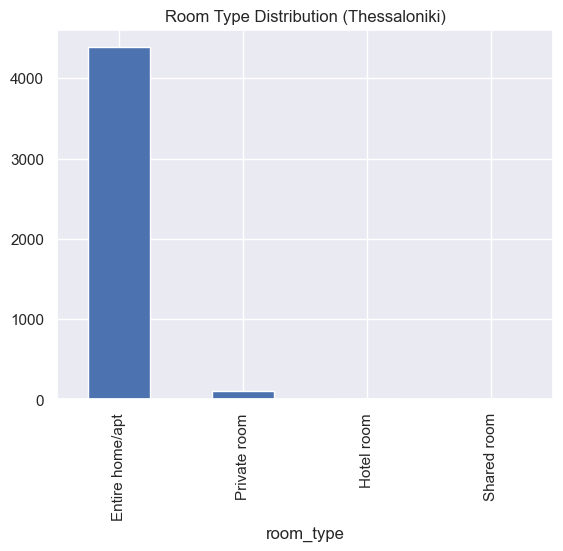

In [9]:
sns.set_theme()
room_type_counts = listings['room_type'].value_counts()
room_type_counts.plot(kind='bar', title='Room Type Distribution (Thessaloniki)')

## Pricing Trends

### Distribution of prices

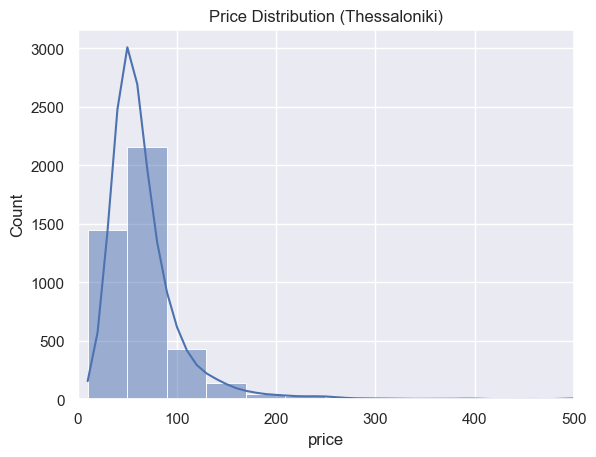

In [10]:
sns.set_theme()
sns.histplot(listings['price'], bins=50, kde=True)
plt.xlim(0, 500)
plt.title('Price Distribution (Thessaloniki)')
plt.show()

As it is seen above, the average price most people prefer to rent for an airbnb is close to 50 euros as the distribution shows 

### Average Price by Room Type

In [11]:
# listings.head()

<Axes: title={'center': 'Average Price by Room Type (Thessaloniki)'}, xlabel='room_type'>

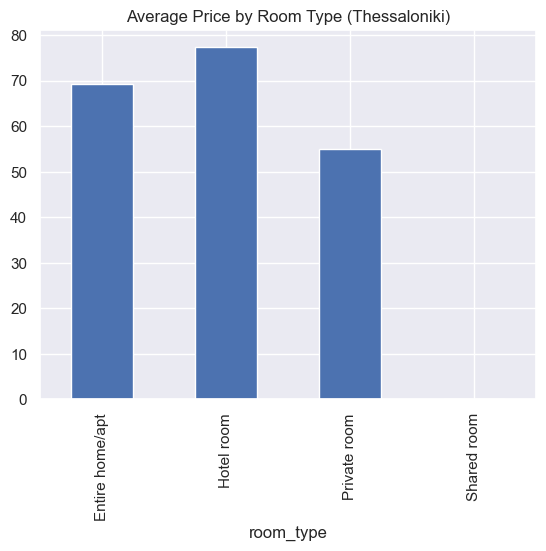

In [12]:
# listings['price'].value_counts()
sns.set_theme()
avg_room_type = listings.groupby('room_type')['price'].mean()
avg_room_type.plot(kind = 'bar', title='Average Price by Room Type (Thessaloniki)')

As it is seen above, most people prefer to rent a hotel room or an apartment 

### Average price by neighborhood

<Axes: title={'center': 'Average Price by Neighborhood (Thessaloniki)'}, xlabel='neighbourhood'>

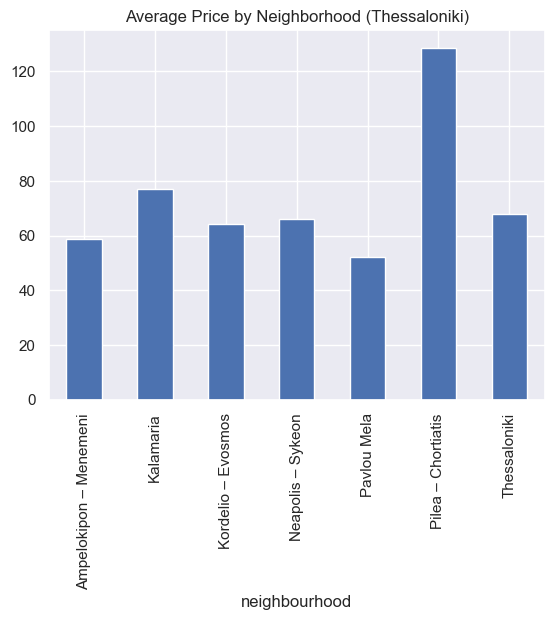

In [13]:
avg_price_neighborhood = listings.groupby('neighbourhood')['price'].mean()
avg_price_neighborhood.plot(kind='bar', title='Average Price by Neighborhood (Thessaloniki)')

## Geographical Analysis

### Visualize listings on a map

In [14]:
import folium
map_thess = folium.Map(location=[40.629269, 22.947412], zoom_start=10)
for _, row in listings.iterrows():
    folium.CircleMarker(
        location=[row['latitude'], row['longitude']],
        radius=1,
        color='blue',
        fill=True
    ).add_to(map_thess)

map_thess.save("thess_listings_map.html")

### Listings by neighborhood

<Axes: title={'center': 'Listings by Neighborhood Group (Thessaloniki)'}, ylabel='count'>

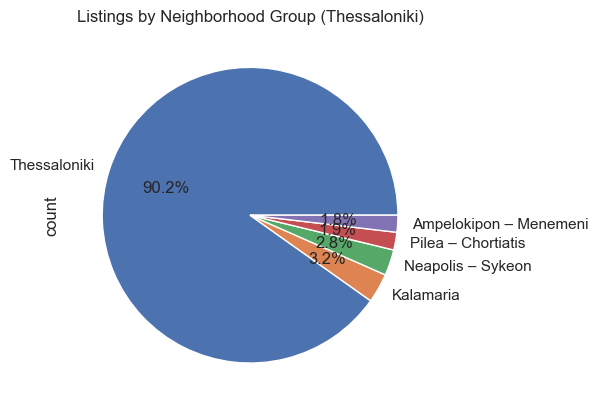

In [15]:
sns.set_theme()
neighborhood_counts = listings['neighbourhood'].value_counts().head()
neighborhood_counts.plot(kind='pie', autopct='%1.1f%%', title='Listings by Neighborhood Group (Thessaloniki)')

## Availability and Reviews

### Distribution of minimum nights

C:\Users\κική\AppData\Local\Temp\ipykernel_13704\3163891878.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(),rotation=30)


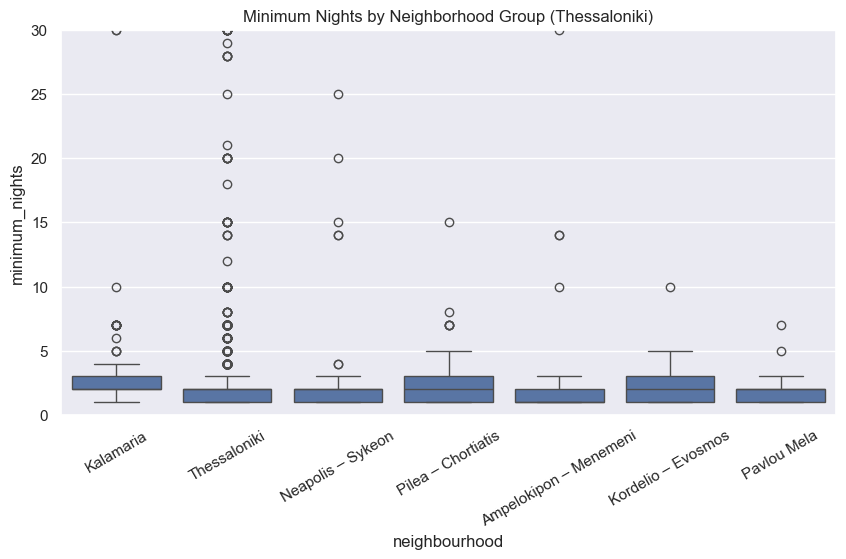

In [25]:
sns.set_theme()
plt.figure(figsize=(10,5))
ax = sns.boxplot(x='neighbourhood', y='minimum_nights', data=listings)
ax.set_xticklabels(ax.get_xticklabels(),rotation=30)
plt.ylim(0, 30)
plt.title('Minimum Nights by Neighborhood Group (Thessaloniki)')
plt.show()

### Reviews per month

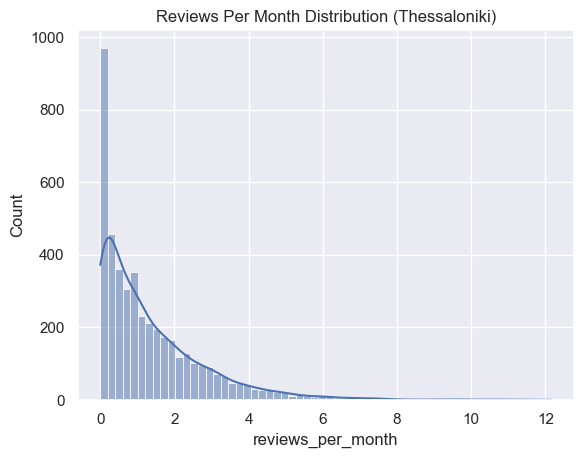

In [17]:
sns.set_theme()
sns.histplot(listings['reviews_per_month'], kde=True)
plt.title('Reviews Per Month Distribution (Thessaloniki)')
plt.show()

### Availability based on minimum nights

<Axes: title={'center': 'Availability by minimum nights (Thessaloniki)'}, xlabel='minimum_nights'>

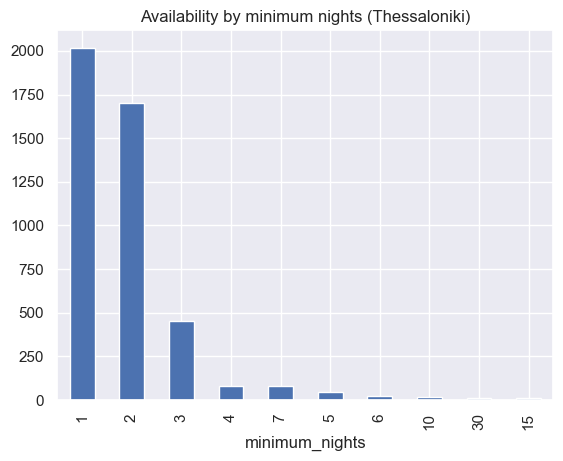

In [18]:
sns.set_theme()
m_nights = listings['minimum_nights'].value_counts().head(10)
m_nights.plot(kind='bar', title='Availability by minimum nights (Thessaloniki)')

### Reviews and lower prices 

In [19]:
listings[['number_of_reviews','price']].value_counts().head(20)
# listings['number_of_reviews'].value_counts(ascending=True)
#.value_counts(ascending=True).head(50)

number_of_reviews  price
0                  50.0     22
                   45.0     16
                   80.0     14
1                  40.0     13
                   50.0     13
2                  80.0     13
4                  50.0     12
0                  52.0     12
                   38.0     12
                   68.0     11
2                  45.0     11
0                  60.0     11
5                  50.0     11
0                  55.0     11
                   49.0     10
2                  70.0     10
0                  48.0     10
2                  50.0     10
0                  40.0     10
                   64.0      9
Name: count, dtype: int64

### Room Type

In [20]:
rtype = listings['room_type'].value_counts()
rtype
# rtype.plot(kind='bar', title="Room Type")

room_type
Entire home/apt    4385
Private room        102
Hotel room            4
Shared room           1
Name: count, dtype: int64

### Last review varies across neighbour

In [21]:
sns.set_theme()
last_neigh = listings.groupby('neighbourhood')['last_review'].value_counts().head(60)
last_neigh
# sns.histplot(last_neigh)
# plt.title('Reviews Per Month Distribution')
# plt.show()

neighbourhood           last_review
Ampelokipon – Menemeni  2024-09-18     5
                        2024-09-22     5
                        2024-09-15     4
                        2024-09-04     3
                        2024-09-08     3
                        2024-02-04     2
                        2024-06-16     2
                        2024-07-31     2
                        2024-08-11     2
                        2024-08-20     2
                        2024-08-25     2
                        2024-09-07     2
                        2024-09-10     2
                        2024-09-16     2
                        2024-09-19     2
                        2019-09-14     1
                        2020-05-25     1
                        2022-01-01     1
                        2022-10-30     1
                        2022-11-19     1
                        2023-06-25     1
                        2023-09-11     1
                        2023-10-29     1
                     

### Analyse trends over time based on last review

In [7]:
listings = listings.dropna(subset=['last_review'])

In [8]:
# Group by 'neighbourhood' and calculate review trends
review_trends = listings.groupby(['neighbourhood', 'last_review']).size().reset_index(name='review_count')

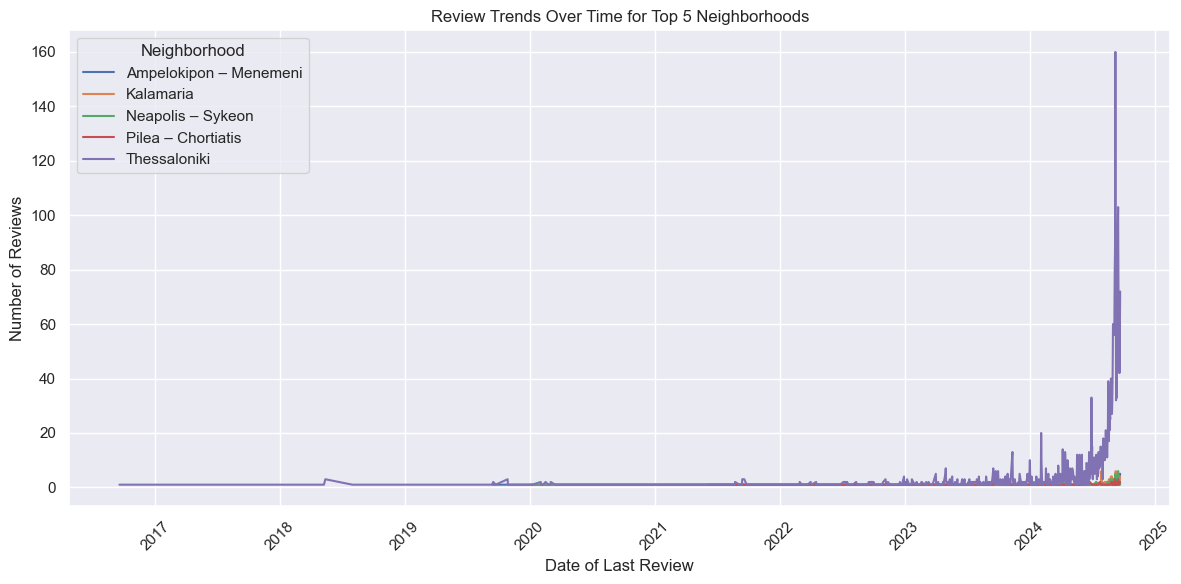

In [9]:
# Visualize review trends over time for the top 5 neighborhoods by total reviews
top_neighborhoods = listings.groupby('neighbourhood')['number_of_reviews'].sum().nlargest(5).index
filtered_trends = review_trends[review_trends['neighbourhood'].isin(top_neighborhoods)]

sns.set_theme()
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=filtered_trends,
    x='last_review',
    y='review_count',
    hue='neighbourhood'
)
plt.title('Review Trends Over Time for Top 5 Neighborhoods')
plt.xlabel('Date of Last Review')
plt.ylabel('Number of Reviews')
plt.legend(title='Neighborhood')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

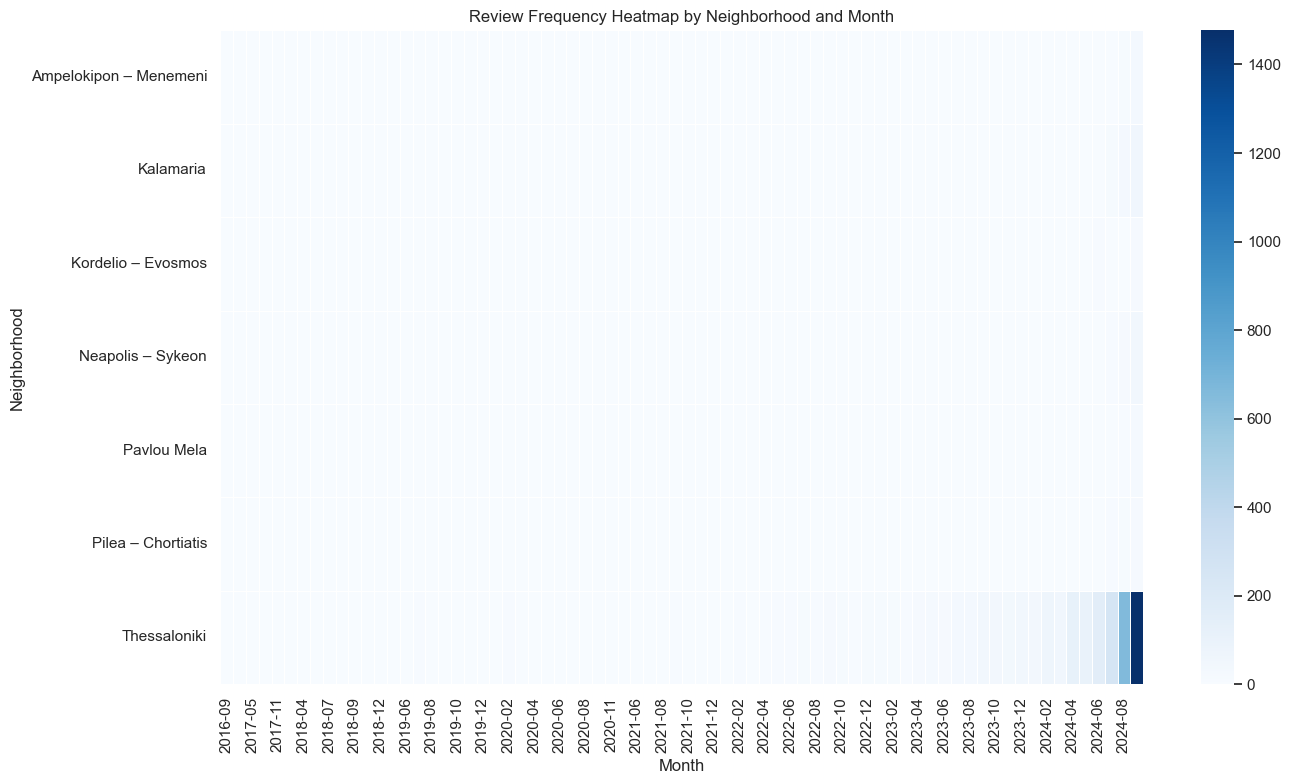

In [10]:
# Heatmap of review frequency by neighborhood and month
listings['month'] = listings['last_review'].dt.to_period('M')
heatmap_data = listings.groupby(['neighbourhood', 'month']).size().unstack(fill_value=0)

plt.figure(figsize=(14, 8))
sns.heatmap(heatmap_data, cmap='Blues', linewidths=0.5)
plt.title('Review Frequency Heatmap by Neighborhood and Month')
plt.xlabel('Month')
plt.ylabel('Neighborhood')
plt.tight_layout()
plt.show()

## Building a predictive model to forecast pricing or occupancy rates

### Import the libraries

In [11]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

### Defining the target and features

In [14]:
# Drop rows with missing prices
listings = listings.dropna(subset=['price']) 

In [15]:
# choose the columns for the model
target = 'price'
features = ['neighbourhood', 'neighbourhood_group', 'latitude', 'longitude',
            'room_type', 'minimum_nights', 'number_of_reviews',
            'reviews_per_month', 'availability_365', 'calculated_host_listings_count']

X = listings[features]
y = listings[target] 

### Train-test split

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

### Preprocessing Pipeline

In [17]:
# Seperating categorical and numerical features
categorical_features = ['neighbourhood', 'neighbourhood_group', 'room_type']
numerical_features = ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews',
                      'reviews_per_month', 'availability_365', 'calculated_host_listings_count']

In [19]:
preprocessor = ColumnTransformer(
    transformers = [
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

### Modeling Pipeline

In [25]:
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=0))
])

### Train the model

In [26]:
model.fit(X_train,y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['latitude', 'longitude',
                                                   'minimum_nights',
                                                   'number_of_reviews',
                                                   'reviews_per_month',
                                                   'availability_365',
                                                   'calculated_host_listings_count']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighbourhood',
                                                   'neighbourhood_group',
                                                   'room_type'])])),
                ('regressor', RandomForestRegressor(random_state=0))])

### Evaluate the model 

In [27]:
y_pred = model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [28]:
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")

Mean Squared Error: 2538.74
R^2 Score: -0.04
